# Notebook 5 — Customer Segmentation: RFM Recap & K-Means Clustering

**Project:** E-Commerce Retail & Fulfillment Analytics — an Amazon Retail / Operations analog
built on the Olist Brazilian e-commerce dataset (Sep-2016 – Oct-2018).

## Where this fits in the project

SQL Domain 2 (`02_customer_rfm_cohorts.sql`) established the single most important structural
fact about this customer base: **96.9% of the 96,096 customers place exactly one order, ever**.
Only 3.1% ever return. That single fact breaks the classic RFM playbook in a specific way —
**Frequency is degenerate** (a near-constant tied at F=1 for 97 of every 100 customers), so a
naive `NTILE(5)` on Frequency mostly splits ties arbitrarily and adds no signal. Q2.1 worked
around this by scoring customers on **Recency x Monetary only**, with repeat-purchase status
folded in as a side flag.

NB4 (Hypothesis Testing) added a second structural fact that classic RFM has **no way to see
at all**: whether an order arrived **late** is, by a wide margin, the strongest driver of
review score in this dataset (F31: Cliff's delta = -0.554, "large"; mean review score
4.29 -> 2.57 for on-time vs. late). A customer can be "recent" and "high-spend" — a Champion by
every RFM standard — and still be one bad delivery away from a 1-star review and silent churn.
RFM, by construction, cannot distinguish a happy Champion from an at-risk one.

**This notebook's job** is to do what a senior analyst would do next: (1) reproduce the
classic RFM segmentation faithfully so it's on record, (2) show precisely where it falls short
using a concrete crosstab, and (3) build a richer **K-Means clustering** on a feature set that
spans *all three* dimensions this project has surfaced as material — monetary value
(NB1/SQL Domain 1-2), delivery experience (NB1/NB3/NB4), and purchase economics (payment
behavior, freight burden). The output is a small set of **named, profiled, actionable
customer segments** that Marketing, CRM and Operations can each act on differently — and a
direct preview of the feature set NB6 (predictive modeling) will lean on.

## Roadmap for the full project

| # | Notebook | Focus |
|---|---|---|
| 1 | `01_data_profiling_and_eda.ipynb` | Profiling, missingness, univariate/bivariate/multivariate EDA |
| 2 | `02_time_series_decomposition.ipynb` | Trend/seasonality decomposition of orders & revenue |
| 3 | `03_geospatial_analysis.ipynb` | State/city geography — demand, delivery, satisfaction, supply-vs-demand |
| 4 | `04_hypothesis_testing.ipynb` | Formal statistical tests — delivery delay vs. review score, category/region effects |
| 5 | `05_customer_segmentation.ipynb` (this notebook) | RFM recap + K-Means clustering, segment profiles |
| 6 | `06_predictive_modeling.ipynb` | Logistic regression — late-delivery & low-review risk |

## Roadmap for this notebook

1. Building the customer-level analytical table (feature engineering)
2. Classic RFM recap (Recency x Monetary quintiles, per SQL Q2.1)
3. Feature set & correlation structure for K-Means
4. Choosing k — elbow method & silhouette analysis
5. Fitting K-Means (k=4) and profiling the segments
6. PCA visualization — what separates the segments?
7. Naming and deep-diving the four segments
8. RFM vs. K-Means: what does clustering see that RFM misses?
9. Regional composition of segments (link to NB3)
10. Cluster stability — bootstrap Adjusted Rand Index
11. Segment-specific recommendations
12. Key Findings Summary

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score

from etl.db import get_engine

%matplotlib inline
sns.set_theme(style="whitegrid", context="notebook", palette="deep")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

engine = get_engine()

# Brazilian state -> IBGE macro-region map (reused from NB3/NB4)
BR_REGION = {
    "AC": "North", "AP": "North", "AM": "North", "PA": "North", "RO": "North", "RR": "North", "TO": "North",
    "AL": "Northeast", "BA": "Northeast", "CE": "Northeast", "MA": "Northeast", "PB": "Northeast",
    "PE": "Northeast", "PI": "Northeast", "RN": "Northeast", "SE": "Northeast",
    "DF": "Central-West", "GO": "Central-West", "MT": "Central-West", "MS": "Central-West",
    "ES": "Southeast", "MG": "Southeast", "RJ": "Southeast", "SP": "Southeast",
    "PR": "South", "RS": "South", "SC": "South",
}
REGION_ORDER = ["North", "Northeast", "Central-West", "Southeast", "South"]
REGION_COLORS = dict(zip(REGION_ORDER, sns.color_palette("deep", 5).as_hex()))

RANDOM_STATE = 42

print("Setup complete.")

Setup complete.


## 1. Building the customer-level analytical table

Both RFM and K-Means need **one row per customer**, aggregated from the order-level
`marts.fact_orders` / `marts.fact_order_items` tables. The aggregation rules below mirror the
conventions established in SQL Domain 2 and NB1-4:

**Population.** Start from the 99,441 orders / 96,096 customers in `dim_customer`. Drop orders
with `order_status IN ('canceled','unavailable')` — these never generated fulfilled revenue
(Q2.1's convention). This removes 1,234 orders and **1,106 customers whose entire order
history is canceled/unavailable** (they have no Recency/Monetary to compute at all), leaving
**94,990 customers with >=1 valid order**.

**Features built per customer:**

| Feature | Definition | Why it matters |
|---|---|---|
| `recency_days` | days between snapshot date (max order date + 1) and the customer's last valid order | classic RFM "R" |
| `frequency` | count of valid orders | classic RFM "F" — **degenerate**: 96.96% of customers have frequency = 1 |
| `monetary` | sum of `order_total_value` across valid orders | classic RFM "M" — lifetime value |
| `avg_order_value` | `monetary / frequency` | basket size, independent of how many trips |
| `avg_review_score` | mean `review_score` across orders with a review | satisfaction (NB1/NB4 central variable) |
| `avg_delivery_delay_days` | mean `delivery_delay_days` across delivered orders with known dates | delivery experience (NB4 F31-32, strongest review driver) |
| `pct_late` | mean of `is_late` (0/1) across delivered orders with known dates | same — fraction of a customer's orders that arrived late |
| `avg_freight_ratio` | mean of `freight_value_total / order_total_value` per order | purchase economics — how freight-burdened this customer's typical basket is |
| `avg_installments` | mean `max_installments` across orders | payment behavior (NB4 H5c: rho=0.38 with order value) |
| `n_categories` | distinct product categories ever purchased | breadth of engagement with the catalog |

**Further filtering.** A small number of customers are missing `avg_review_score` (no review
left on any order, 0.72%), delivery-delay fields (order not yet delivered or missing
timestamps, 1.73%), `avg_freight_ratio` (0.01%) or `avg_installments` (0.001%). These are
dropped, leaving the final analytical table **`cust` -> `cust_clean`, n = 92,746
(97.64% of the 94,990 valid-order customers; 96.5% of all 96,096 customers)**.

In [2]:
orders = pd.read_sql("""
    SELECT
        customer_unique_id, order_id, order_status, order_purchase_date,
        order_total_value, freight_value_total, review_score,
        delivery_delay_days, is_late, is_delivered, max_installments,
        n_items, customer_state
    FROM marts.fact_orders
""", engine)
orders["order_purchase_date"] = pd.to_datetime(orders["order_purchase_date"])

items = pd.read_sql("""
    SELECT oi.order_id, dp.product_category_name_english AS category
    FROM marts.fact_order_items oi
    JOIN marts.dim_product dp ON dp.product_id = oi.product_id
    WHERE dp.product_category_name_english IS NOT NULL
""", engine)

n_total_customers = orders["customer_unique_id"].nunique()
valid = orders[~orders["order_status"].isin(["canceled", "unavailable"])].copy()
n_valid_customers = valid["customer_unique_id"].nunique()
print(f"Total orders: {len(orders):,} | Total customers: {n_total_customers:,}")
print(f"Valid orders: {len(valid):,} | Customers with >=1 valid order: {n_valid_customers:,}")
print(f"Customers with 0 valid orders (excluded): {n_total_customers - n_valid_customers:,}")

# Category diversity per customer
order_cust = valid[["order_id", "customer_unique_id"]]
n_categories = (
    items.merge(order_cust, on="order_id", how="inner")
    .groupby("customer_unique_id")["category"].nunique()
    .rename("n_categories")
)

# Snapshot date for recency
snapshot_date = valid["order_purchase_date"].max() + pd.Timedelta(days=1)
print(f"\nSnapshot date: {snapshot_date.date()}")

# Core RFM
rfm = valid.groupby("customer_unique_id").agg(
    frequency=("order_id", "count"),
    monetary=("order_total_value", "sum"),
    last_order_date=("order_purchase_date", "max"),
    customer_state=("customer_state", "first"),
).reset_index()
rfm["recency_days"] = (snapshot_date - rfm["last_order_date"]).dt.days
rfm["avg_order_value"] = rfm["monetary"] / rfm["frequency"]
print(f"\n% customers with frequency == 1: {(rfm['frequency'] == 1).mean() * 100:.2f}%")

# Review / delivery experience
avg_review = (
    valid.dropna(subset=["review_score"])
    .groupby("customer_unique_id")["review_score"].mean()
    .rename("avg_review_score")
)
delivered = valid[valid["is_delivered"] & valid["delivery_delay_days"].notna() & valid["is_late"].notna()]
delay_agg = delivered.groupby("customer_unique_id").agg(
    avg_delivery_delay_days=("delivery_delay_days", "mean"),
    pct_late=("is_late", "mean"),
).reset_index()

# Purchase economics
valid["freight_ratio"] = np.where(
    valid["order_total_value"] > 0,
    valid["freight_value_total"] / valid["order_total_value"],
    np.nan,
)
freight_agg = valid.groupby("customer_unique_id")["freight_ratio"].mean().rename("avg_freight_ratio")
inst_agg = valid.groupby("customer_unique_id")["max_installments"].mean().rename("avg_installments")

# Assemble
cust = (
    rfm.merge(avg_review, on="customer_unique_id", how="left")
       .merge(delay_agg, on="customer_unique_id", how="left")
       .merge(freight_agg, on="customer_unique_id", how="left")
       .merge(inst_agg, on="customer_unique_id", how="left")
       .merge(n_categories, on="customer_unique_id", how="left")
)
cust["n_categories"] = cust["n_categories"].fillna(0).astype(int)

print("\nMissingness in raw cust table (count, % of n_valid_customers):")
miss = cust[["avg_review_score", "avg_delivery_delay_days", "pct_late", "avg_freight_ratio", "avg_installments"]].isna().sum()
print(pd.DataFrame({"n_missing": miss, "pct_missing": (100 * miss / len(cust)).round(3)}))

cust_clean = cust.dropna(
    subset=["avg_review_score", "avg_delivery_delay_days", "avg_freight_ratio", "avg_installments"]
).copy()
cust_clean["region"] = cust_clean["customer_state"].map(BR_REGION)
cust_clean["is_repeat"] = (cust_clean["frequency"] > 1).astype(int)
cust_clean["log_monetary"] = np.log1p(cust_clean["monetary"])
cust_clean["log_recency"] = np.log1p(cust_clean["recency_days"])
cust_clean["log_avg_order_value"] = np.log1p(cust_clean["avg_order_value"])

print(f"\ncust_clean: {len(cust_clean):,} rows "
      f"({100 * len(cust_clean) / len(cust):.2f}% of valid-order customers, "
      f"{100 * len(cust_clean) / n_total_customers:.2f}% of all customers)")
cust_clean.head()

Total orders: 99,441 | Total customers: 96,096
Valid orders: 98,207 | Customers with >=1 valid order: 94,990
Customers with 0 valid orders (excluded): 1,106

Snapshot date: 2018-09-04

% customers with frequency == 1: 96.96%



Missingness in raw cust table (count, % of n_valid_customers):
                         n_missing  pct_missing
avg_review_score               685        0.721
avg_delivery_delay_days       1640        1.726
pct_late                      1640        1.726
avg_freight_ratio                7        0.007
avg_installments                 1        0.001

cust_clean: 92,746 rows (97.64% of valid-order customers, 96.51% of all customers)


,customer_unique_id,frequency,monetary,last_order_date,customer_state,recency_days,avg_order_value,avg_review_score,avg_delivery_delay_days,pct_late,avg_freight_ratio,avg_installments,n_categories,region,is_repeat,log_monetary,log_recency,log_avg_order_value
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.900,2018-05-10,SP,117,141.900,5.000,-4.133,0.000,0.085,8.000,1,Southeast,0,4.962,4.771,4.962
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.190,2018-05-07,SP,120,27.190,4.000,-4.248,0.000,0.305,1.000,1,Southeast,0,3.339,4.796,3.339
2,0000f46a3911fa3c0805444483337064,1,86.220,2017-03-10,SC,543,86.220,3.000,-1.390,0.000,0.200,8.000,1,South,0,4.468,6.299,4.468
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.620,2017-10-12,PA,327,43.620,4.000,-11.109,0.000,0.404,4.000,1,North,0,3.798,5.793,3.798
4,0004aac84e0df4da2b147fca70cf8255,1,196.890,2017-11-14,SP,294,196.890,5.000,-7.035,0.000,0.086,6.000,1,Southeast,0,5.288,5.687,5.288


## 2. Classic RFM recap (Recency x Monetary quintiles)

Reproducing SQL Q2.1 in Python, for completeness and so it can feed the crosstab in Section 8.
Per the header note in `02_customer_rfm_cohorts.sql`, **Frequency is excluded from the
quintile scoring** (96.96% tie at F=1, so `NTILE(5)` on Frequency would mostly split ties
arbitrarily) — it is folded in afterward as an `is_repeat` flag. Customers are scored into
quintiles on `recency_days` (5 = most recent) and `monetary` (5 = highest spend), then bucketed
into 5 named segments using the same logic as Q2.1:

- **Champions** (r>=4, m>=4): recent AND high spend
- **High-Value Lapsed** (r<=2, m>=4): high spend but haven't ordered in a long time — win-back priority
- **New/Recent Low-Spend** (r>=4, m<=2): ordered recently but small basket
- **Low-Value Lapsed** (r<=2, m<=2): low spend, long gone
- **Mid-Value**: everything in between

In [3]:
cust_clean["r_score"] = pd.qcut(cust_clean["recency_days"].rank(method="first"), 5, labels=[5, 4, 3, 2, 1]).astype(int)
cust_clean["m_score"] = pd.qcut(cust_clean["monetary"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)

def rfm_segment(row):
    r, m = row["r_score"], row["m_score"]
    if r >= 4 and m >= 4:
        return "Champions (recent + high spend)"
    if r <= 2 and m >= 4:
        return "High-Value Lapsed (win-back priority)"
    if r >= 4 and m <= 2:
        return "New/Recent Low-Spend"
    if r <= 2 and m <= 2:
        return "Low-Value Lapsed"
    return "Mid-Value"

cust_clean["rfm_segment"] = cust_clean.apply(rfm_segment, axis=1)

rfm_summary = cust_clean.groupby("rfm_segment").agg(
    n_customers=("customer_unique_id", "count"),
    avg_monetary=("monetary", "mean"),
    avg_recency_days=("recency_days", "mean"),
    total_revenue=("monetary", "sum"),
    pct_repeat=("is_repeat", "mean"),
).reset_index()
rfm_summary["pct_customers"] = 100 * rfm_summary["n_customers"] / rfm_summary["n_customers"].sum()
rfm_summary["pct_revenue"] = 100 * rfm_summary["total_revenue"] / rfm_summary["total_revenue"].sum()
rfm_summary["pct_repeat"] = 100 * rfm_summary["pct_repeat"]
rfm_summary = rfm_summary.sort_values("pct_revenue", ascending=False).reset_index(drop=True)
rfm_summary[["rfm_segment", "n_customers", "pct_customers", "avg_monetary", "avg_recency_days",
              "pct_revenue", "pct_repeat"]]

,rfm_segment,n_customers,pct_customers,avg_monetary,avg_recency_days,pct_revenue,pct_repeat
0,Champions (recent + high spend),15288,16.484,306.472,96.475,30.607,6.554
1,Mid-Value,33398,36.010,134.956,234.214,29.443,2.779
2,High-Value Lapsed (win-back priority),14446,15.576,310.093,398.374,29.263,5.399
3,Low-Value Lapsed,15334,16.533,55.776,401.474,5.587,0.561
4,New/Recent Low-Spend,14280,15.397,54.681,95.015,5.101,0.539


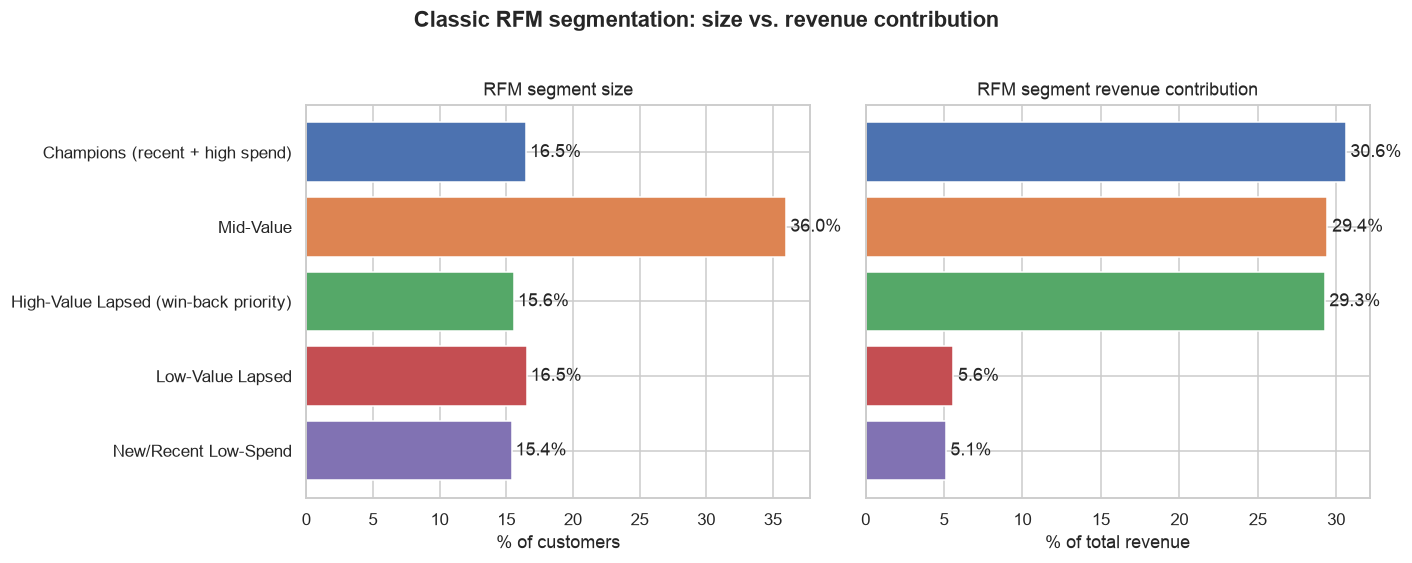

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

order = rfm_summary["rfm_segment"]
colors = sns.color_palette("deep", len(order))

axes[0].barh(order, rfm_summary["pct_customers"], color=colors)
axes[0].set_xlabel("% of customers")
axes[0].set_title("RFM segment size")
axes[0].invert_yaxis()
for i, v in enumerate(rfm_summary["pct_customers"]):
    axes[0].text(v + 0.3, i, f"{v:.1f}%", va="center")

axes[1].barh(order, rfm_summary["pct_revenue"], color=colors)
axes[1].set_xlabel("% of total revenue")
axes[1].set_title("RFM segment revenue contribution")
axes[1].invert_yaxis()
axes[1].set_yticklabels([])
for i, v in enumerate(rfm_summary["pct_revenue"]):
    axes[1].text(v + 0.3, i, f"{v:.1f}%", va="center")

plt.suptitle("Classic RFM segmentation: size vs. revenue contribution", y=1.02, fontweight="bold")
plt.tight_layout()
plt.show()

**FINDING #37 — Classic RFM recap confirms a healthy-looking revenue base, but tells us
nothing about delivery experience.** Champions + High-Value Lapsed together are just 32.1% of
customers but 59.9% of revenue — a textbook Pareto pattern. High-Value Lapsed (15.6% of
customers, 29.3% of revenue, avg. recency 398 days) is the single largest win-back
opportunity by dollar value. So far, so standard. The blind spot is structural: **every one of
these five segments is defined purely by *when* and *how much* a customer spent — nothing
in this table reflects whether their package arrived on time or how they rated the
experience.** Section 8 will show concretely how much this matters.

## 3. Feature set & correlation structure for K-Means

K-Means gets a **10-feature set** spanning every dimension this project has found to matter:

| Feature | Dimension | Transform | Rationale |
|---|---|---|---|
| `log_recency` | RFM | `log1p(recency_days)` | right-skewed (NB1 convention: log-transform monetary-like skew) |
| `log_monetary` | RFM | `log1p(monetary)` | lifetime value, right-skewed |
| `log_avg_order_value` | RFM | `log1p(avg_order_value)` | basket size |
| `frequency` | RFM | raw | mostly 1, but the long tail (up to 17) is exactly the repeat-customer signal |
| `avg_review_score` | Satisfaction | raw (1-5) | NB1/NB4 central outcome variable |
| `avg_delivery_delay_days` | Delivery | raw | NB4 F31-32: strongest review driver |
| `pct_late` | Delivery | raw (0-1) | fraction of a customer's orders that missed the estimate |
| `avg_freight_ratio` | Economics | raw (0-1) | freight burden as a share of basket |
| `avg_installments` | Economics | raw | NB4 H5c: correlates with order value (rho=0.38) |
| `n_categories` | Engagement | raw | catalog breadth |

All 10 features are standardized (zero mean, unit variance) with `StandardScaler` before
clustering — K-Means uses Euclidean distance, so unscaled features (e.g. `monetary` in R\$ vs.
`avg_review_score` in 1-5) would let the largest-magnitude feature dominate.

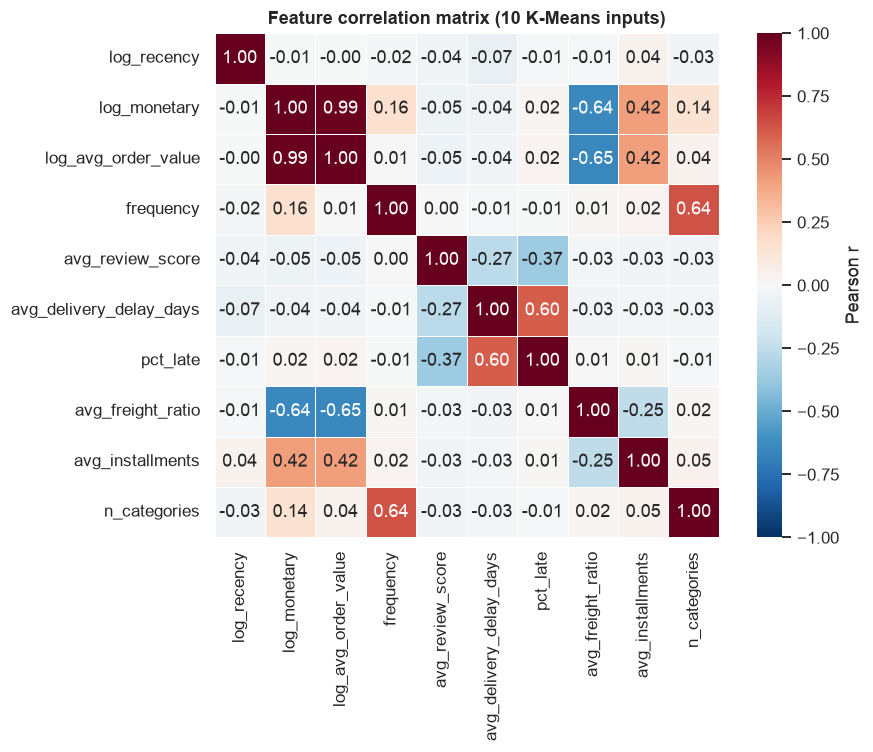

In [5]:
feature_cols = [
    "log_recency", "log_monetary", "log_avg_order_value", "frequency",
    "avg_review_score", "avg_delivery_delay_days", "pct_late",
    "avg_freight_ratio", "avg_installments", "n_categories",
]

corr = cust_clean[feature_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, cbar_kws={"label": "Pearson r"}, ax=ax)
ax.set_title("Feature correlation matrix (10 K-Means inputs)", fontweight="bold")
plt.tight_layout()
plt.show()

**Multicollinearity, acknowledged.** Two pairs stand out: `log_monetary` and
`log_avg_order_value` correlate at **r=0.99** (expected — for the 96.96% of customers with
frequency=1, these are mathematically identical), and `log_monetary` vs. `avg_freight_ratio`
at **r=-0.64** (bigger baskets dilute the fixed freight cost as a share of total). A purist
might drop one of the two monetary features to avoid double-weighting "spend" in the Euclidean
distance. We keep both deliberately: K-Means has no independence *assumption* to violate (unlike
OLS), and the practical effect — confirmed below — is that **"spend level" becomes an
unmistakably dominant axis of separation**, which is exactly the kind of clear, business-legible
structure a segmentation should surface. The PCA loadings in Section 6 make this explicit
rather than hiding it.

## 4. Choosing k — elbow method & silhouette analysis

Two standard diagnostics, computed for k=2..10:

- **Inertia (elbow method)**: within-cluster sum of squared distances. Always decreases with
  k; we look for the point where the marginal decrease flattens.
- **Silhouette score**: how well-separated clusters are (-1 to 1; higher is better). Computed
  on a fixed random sample of 10,000 customers for tractability (`silhouette_score` is
  O(n^2)), with a fixed seed for reproducibility.

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cust_clean[feature_cols].values)

rng = np.random.RandomState(RANDOM_STATE)
sample_idx = rng.choice(len(X_scaled), size=10000, replace=False)

k_results = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled[sample_idx], labels[sample_idx])
    k_results.append({"k": k, "inertia": km.inertia_, "silhouette": sil})

k_results = pd.DataFrame(k_results)
k_results

,k,inertia,silhouette
0,2,"766,285.252",0.191
1,3,"641,067.984",0.220
2,4,"525,454.454",0.240
3,5,"472,397.337",0.210
4,6,"435,420.991",0.211
5,7,"405,834.466",0.216
6,8,"383,130.399",0.193
7,9,"360,377.906",0.223
8,10,"342,638.343",0.203


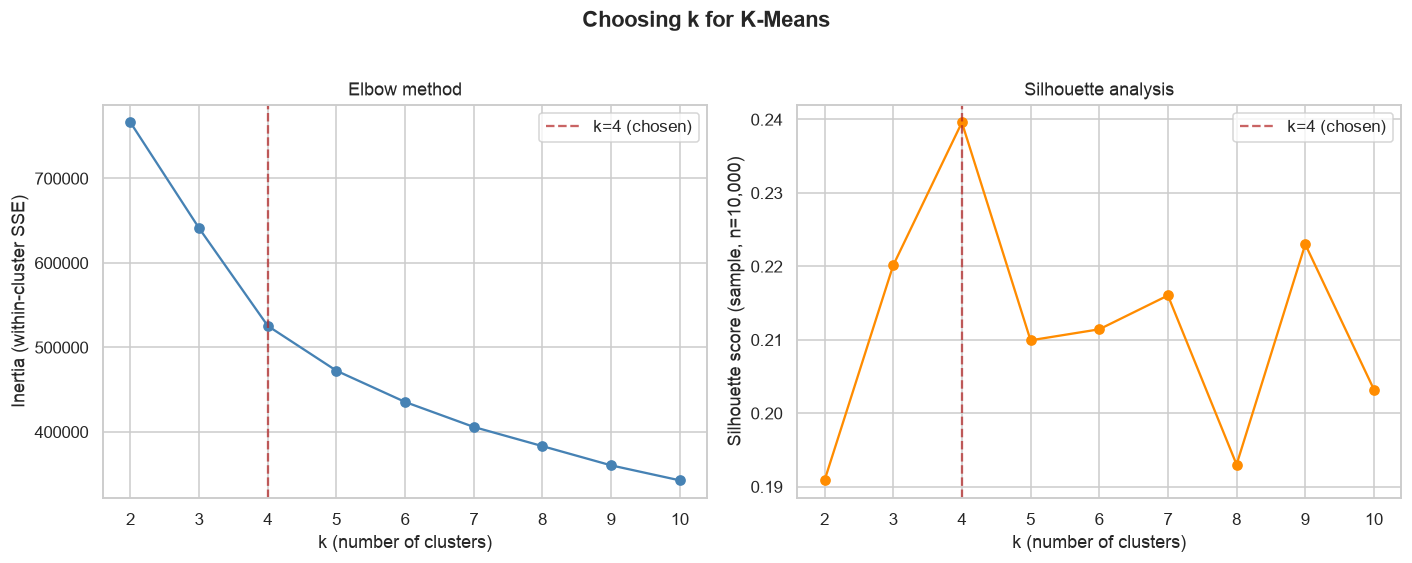

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(k_results["k"], k_results["inertia"], marker="o", color="steelblue")
axes[0].set_xlabel("k (number of clusters)")
axes[0].set_ylabel("Inertia (within-cluster SSE)")
axes[0].set_title("Elbow method")
axes[0].axvline(4, color="firebrick", linestyle="--", alpha=0.7, label="k=4 (chosen)")
axes[0].legend()

axes[1].plot(k_results["k"], k_results["silhouette"], marker="o", color="darkorange")
axes[1].set_xlabel("k (number of clusters)")
axes[1].set_ylabel("Silhouette score (sample, n=10,000)")
axes[1].set_title("Silhouette analysis")
axes[1].axvline(4, color="firebrick", linestyle="--", alpha=0.7, label="k=4 (chosen)")
axes[1].legend()

plt.suptitle("Choosing k for K-Means", y=1.02, fontweight="bold")
plt.tight_layout()
plt.show()

**FINDING #38 — k=4 is the chosen number of clusters.** It is the **silhouette-maximizing
value** among k=2..10 (0.240, vs. 0.190-0.223 for every other k), and sits at a visible elbow
inflection — the inertia drop from k=3 to k=4 (-18.0%) is the largest single-step drop in the
range, with k=4 to k=5 dropping off to -10.1%. A silhouette of ~0.24 is **modest in absolute
terms** — real customer-behavior data rarely produces the sharply-separated, near-1.0
silhouettes seen in synthetic examples — but it is the clear local maximum, and (Section 10
confirms) the resulting clusters are highly *stable* even if not perfectly *separated*. k=4
also has the practical advantage of being small enough to name and act on individually.

## 5. Fitting K-Means (k=4) and profiling the segments

Fit `KMeans(n_clusters=4, random_state=42, n_init=10)` on the scaled 10-feature matrix and
attach the cluster label back to `cust_clean`. The profile table below reports the mean of
each raw (unscaled) feature per cluster, alongside size, revenue share and repeat-purchase
rate — everything needed to read the segments in business terms.

In [8]:
kmeans = KMeans(n_clusters=4, random_state=RANDOM_STATE, n_init=10)
cust_clean["cluster"] = kmeans.fit_predict(X_scaled)

profile_cols = ["recency_days", "frequency", "monetary", "avg_order_value",
                 "avg_review_score", "avg_delivery_delay_days", "pct_late",
                 "avg_freight_ratio", "avg_installments", "n_categories"]

profile = cust_clean.groupby("cluster")[profile_cols].mean()
sizes = cust_clean["cluster"].value_counts().sort_index()
profile.insert(0, "n_customers", sizes)
profile["pct_customers"] = 100 * sizes / sizes.sum()
profile["pct_revenue"] = 100 * cust_clean.groupby("cluster")["monetary"].sum() / cust_clean["monetary"].sum()
profile["pct_repeat"] = 100 * cust_clean.groupby("cluster")["is_repeat"].mean()

profile.round(3)

,n_customers,recency_days,frequency,monetary,avg_order_value,avg_review_score,avg_delivery_delay_days,pct_late,avg_freight_ratio,avg_installments,n_categories,pct_customers,pct_revenue,pct_repeat
cluster,,,,,,,,,,,,,,
0,41814,246.428,1.009,64.707,64.208,4.334,-12.514,0.000,0.286,1.782,1.000,45.084,17.675,0.899
1,7319,220.318,1.011,172.784,171.181,2.551,9.459,0.997,0.212,2.984,1.001,7.891,8.261,1.148
2,2347,213.433,1.855,298.075,176.251,3.883,-12.996,0.053,0.220,3.676,2.045,2.531,4.570,71.453
3,41266,245.905,1.018,257.802,254.216,4.269,-13.402,0.001,0.129,4.004,1.000,44.494,69.495,1.784


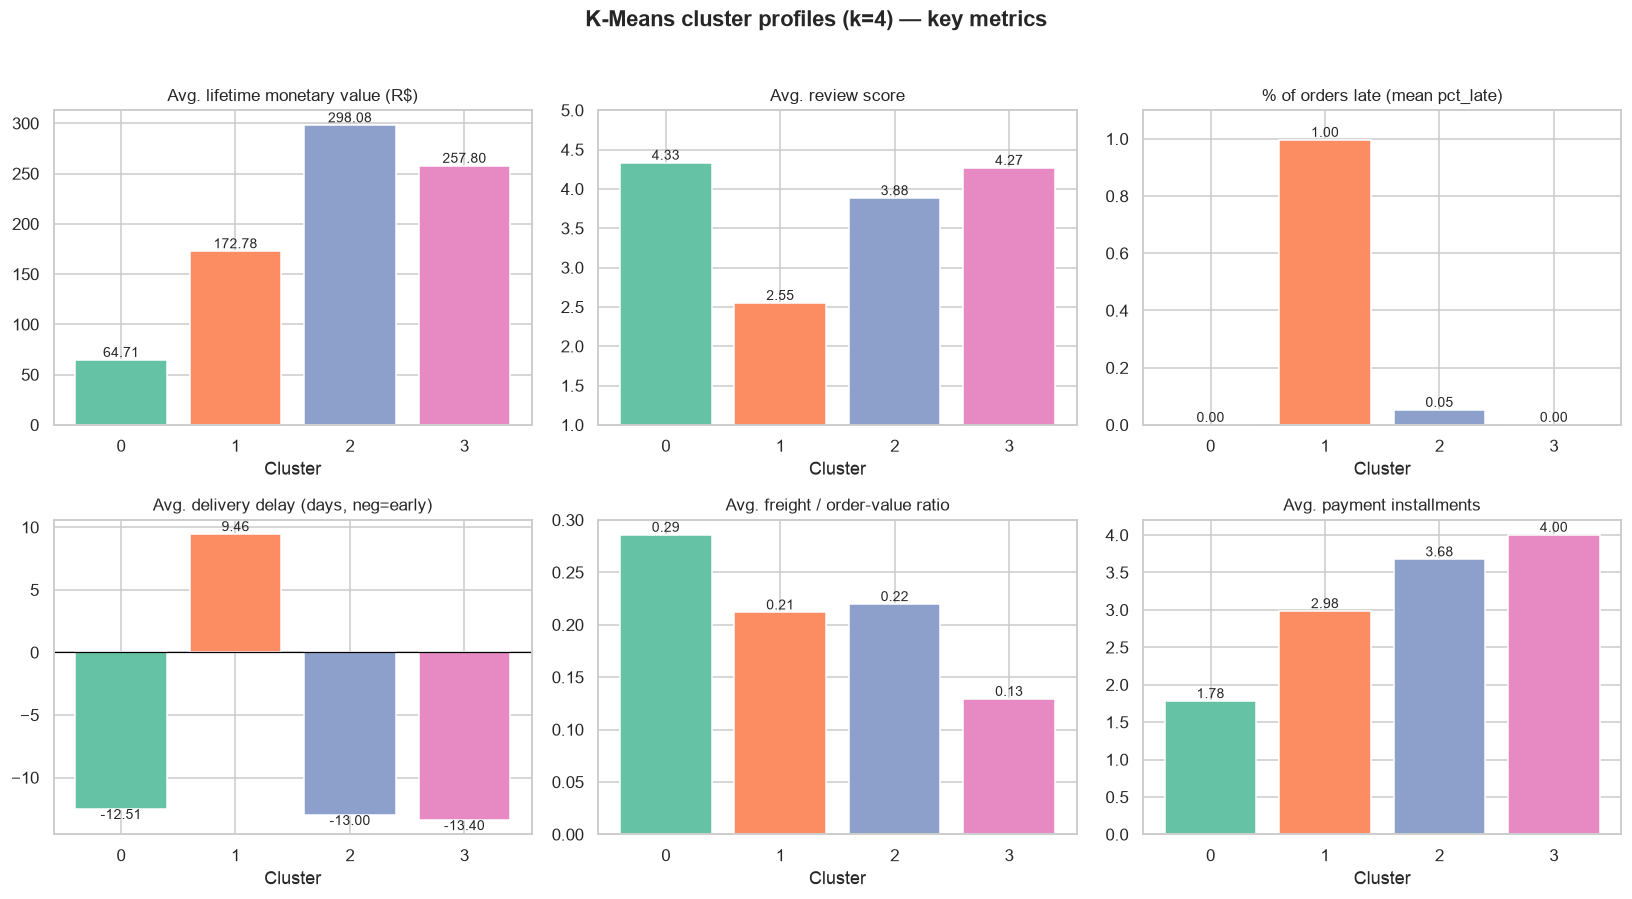

In [9]:
metrics = [
    ("monetary", "Avg. lifetime monetary value (R$)", None),
    ("avg_review_score", "Avg. review score", (1, 5)),
    ("pct_late", "% of orders late (mean pct_late)", (0, 1.1)),
    ("avg_delivery_delay_days", "Avg. delivery delay (days, neg=early)", None),
    ("avg_freight_ratio", "Avg. freight / order-value ratio", None),
    ("avg_installments", "Avg. payment installments", None),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
cluster_colors = sns.color_palette("Set2", 4)

for ax, (col, title, ylim) in zip(axes.flat, metrics):
    bars = ax.bar(profile.index.astype(str), profile[col], color=cluster_colors)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Cluster")
    if ylim:
        ax.set_ylim(*ylim)
    for bar, v in zip(bars, profile[col]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                f"{v:.2f}", ha="center", va="bottom" if v >= 0 else "top", fontsize=9)
    if col == "avg_delivery_delay_days":
        ax.axhline(0, color="black", linewidth=0.8)

plt.suptitle("K-Means cluster profiles (k=4) — key metrics", y=1.02, fontweight="bold")
plt.tight_layout()
plt.show()

## 6. PCA visualization — what separates the segments?

Projecting the 10-dimensional scaled feature space onto its first two principal components
gives a 2D map of the customer base, and the **loadings** (how much each original feature
contributes to each component) tell us *what* those axes represent in business terms.

In [10]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
pcs = pca.fit_transform(X_scaled)
cust_clean["pc1"] = pcs[:, 0]
cust_clean["pc2"] = pcs[:, 1]

print(f"Explained variance ratio: PC1={pca.explained_variance_ratio_[0]:.1%}, "
      f"PC2={pca.explained_variance_ratio_[1]:.1%}, "
      f"cumulative={pca.explained_variance_ratio_[:2].sum():.1%}")

loadings = pd.DataFrame(pca.components_.T, index=feature_cols, columns=["PC1", "PC2"])
loadings.sort_values("PC1", ascending=False)

Explained variance ratio: PC1=27.9%, PC2=18.5%, cumulative=46.3%


,PC1,PC2
log_monetary,0.576,-0.009
log_avg_order_value,0.569,0.000
avg_installments,0.339,-0.009
n_categories,0.095,-0.057
frequency,0.089,-0.060
pct_late,0.017,0.637
log_recency,0.006,-0.039
avg_delivery_delay_days,-0.012,0.608
avg_review_score,-0.037,-0.465
avg_freight_ratio,-0.460,0.003


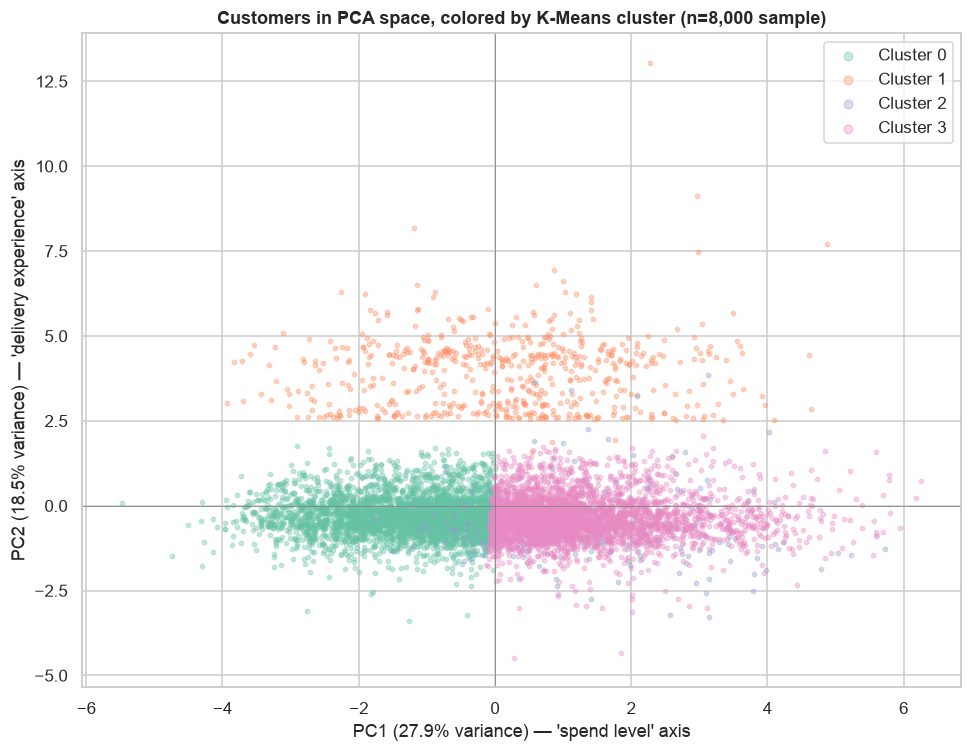

In [11]:
fig, ax = plt.subplots(figsize=(9, 7))

sample = cust_clean.sample(n=8000, random_state=RANDOM_STATE)
for c in sorted(sample["cluster"].unique()):
    sub = sample[sample["cluster"] == c]
    ax.scatter(sub["pc1"], sub["pc2"], s=8, alpha=0.35, color=cluster_colors[c], label=f"Cluster {c}")

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance) — 'spend level' axis")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance) — 'delivery experience' axis")
ax.set_title("Customers in PCA space, colored by K-Means cluster (n=8,000 sample)", fontweight="bold")
ax.legend(markerscale=2)
ax.axhline(0, color="grey", linewidth=0.5)
ax.axvline(0, color="grey", linewidth=0.5)

plt.tight_layout()
plt.show()

**FINDING #39 — Two axes explain ~46% of the variance, and they map cleanly onto
"how much they spend" and "how good their delivery experience was."** PC1 (27.9% of
variance) is dominated by `log_monetary` (+0.58), `log_avg_order_value` (+0.57) and
`avg_installments` (+0.34) on the positive side, and `avg_freight_ratio` (-0.46) on the
negative side — i.e. **PC1 is a "spend level" axis**: customers who spend more, pay in more
installments, and pay proportionally less in freight sit on the right. PC2 (18.5%) is
dominated by `pct_late` (+0.64) and `avg_delivery_delay_days` (+0.61) on the positive side and
`avg_review_score` (-0.47) on the negative side — **PC2 is a "delivery experience" axis**:
customers whose orders ran late and who rated their experience poorly sit at the top.
The scatter shows the four K-Means clusters occupy visually distinct regions of this map —
Cluster 1 (At-Risk) is pulled sharply toward the top (poor delivery experience) regardless of
where it sits on the spend axis, while Clusters 0 and 3 split cleanly along the spend axis at
similar (good) delivery-experience levels. This is strong qualitative confirmation that
K-Means recovered the two dimensions this project has independently identified as most
material — value and delivery experience — without being told to.

## 7. Naming and deep-diving the four segments

With profiles (Section 5) and the PCA map (Section 6) in hand, each cluster gets a
business-legible name.

In [12]:
segment_names = {
    0: "Budget Satisfied",
    1: "At-Risk: Late & Unhappy",
    2: "Loyal Repeat Customers",
    3: "Core High-Value",
}
cust_clean["segment"] = cust_clean["cluster"].map(segment_names)

named_profile = profile.rename(index=segment_names)
named_profile.index.name = "segment"
named_profile[["n_customers", "pct_customers", "pct_revenue", "monetary", "avg_review_score",
               "pct_late", "avg_delivery_delay_days", "avg_freight_ratio", "avg_installments",
               "pct_repeat"]].round(3)

,n_customers,pct_customers,pct_revenue,monetary,avg_review_score,pct_late,avg_delivery_delay_days,avg_freight_ratio,avg_installments,pct_repeat
segment,,,,,,,,,,
Budget Satisfied,41814,45.084,17.675,64.707,4.334,0.000,-12.514,0.286,1.782,0.899
At-Risk: Late & Unhappy,7319,7.891,8.261,172.784,2.551,0.997,9.459,0.212,2.984,1.148
Loyal Repeat Customers,2347,2.531,4.570,298.075,3.883,0.053,-12.996,0.220,3.676,71.453
Core High-Value,41266,44.494,69.495,257.802,4.269,0.001,-13.402,0.129,4.004,1.784


### Cluster 3 — "Core High-Value" (44.5% of customers, **69.5% of revenue**)

The backbone of the business. Average lifetime spend R\$257.80 (highest of the three
single-purchase-dominated clusters), average review 4.27/5, deliveries arrive **13.4 days
ahead of estimate on average** with essentially 0% late (0.06%), the lowest freight burden
(12.9% of basket vs. 21-29% elsewhere — consistent with larger baskets diluting a roughly
fixed freight cost), and the highest use of installment payment (avg. 4.0 installments,
consistent with NB4 H5c's finding that installments track order value). 99.1% are *technically*
one-time buyers by `frequency`, but they are buying big and having a great experience —
prime candidates for a loyalty/Prime-style program that converts a good one-off experience
into a second purchase.

### Cluster 0 — "Budget Satisfied" (45.1% of customers, 17.7% of revenue)

The mirror image of Cluster 3 on the spend axis, but with an *equally* good delivery
experience: average spend R\$64.71, review 4.33/5 (the **highest** average review of any
segment), deliveries 12.5 days ahead of estimate on average, pct_late effectively 0%. The
freight ratio is the highest of all segments at 28.6% — for a ~R\$65 basket, a roughly fixed
freight cost is a much larger share. This is the long tail of small, single-item, low-value
orders that nonetheless deliver a great experience. The opportunity here is **basket size**,
not satisfaction or delivery: cross-sell / bundle / free-shipping-threshold tactics that move
customers from Cluster 0 toward Cluster 3's spend level, without needing to fix anything about
their (already excellent) delivery experience.

### Cluster 1 — "At-Risk: Late & Unhappy" (7.9% of customers, 8.3% of revenue)

The segment K-Means found that RFM cannot see at all. Average spend R\$172.78 — solidly
mid-to-high, **not** a low-value segment — but average review **2.55/5**, the lowest of any
segment by a wide margin, and **99.7% of these customers had every tracked order arrive
late**, averaging **9.5 days late** against the estimate. This single cluster is essentially a
direct re-derivation of NB4's F31 finding (is_late -> review score, Cliff's delta=-0.554,
"large") at the customer level: **delivery failure, not price sensitivity or product fit, is
what defines this segment.** These are mid-value customers who, on paper (RFM), look like
solid contributors — and Section 8 shows exactly how many of them RFM would file under
"Champion."

### Cluster 2 — "Loyal Repeat Customers" (2.5% of customers, 4.6% of revenue)

The only segment where `frequency` is materially above 1 (mean 1.86, vs. ~1.01 elsewhere) and
**71.5% have placed 2+ orders** (vs. ~1-2% in every other cluster). They have the **highest
average lifetime monetary value of any segment (R\$298.08)**, buy across more categories (mean
2.05 vs. ~1.0 elsewhere), and have a moderate review average (3.88) with a slightly elevated
5.3% late rate. This is the closest thing this marketplace has to an existing "repeat
customer" archetype — small in size (2.5%) but disproportionately valuable per-head, and the
natural target for retention-focused CRM (the segment most likely to respond to a loyalty
program because they've already demonstrated repeat behavior).

## 8. RFM vs. K-Means: what does clustering see that RFM misses?

The crosstab below shows, for each classic RFM segment (rows), what % of its customers fall
into each K-Means segment (columns). If RFM and K-Means captured the same information, each
row would concentrate in one or two columns tied to spend level. The "At-Risk: Late & Unhappy"
column (Cluster 1) is the test: does it appear *only* in the low-value RFM segments, or
*everywhere*?

In [13]:
ct_counts = pd.crosstab(cust_clean["rfm_segment"], cust_clean["segment"])
ct_pct = pd.crosstab(cust_clean["rfm_segment"], cust_clean["segment"], normalize="index") * 100

# order columns/rows for readability
seg_order = ["Budget Satisfied", "At-Risk: Late & Unhappy", "Loyal Repeat Customers", "Core High-Value"]
rfm_order = ["Champions (recent + high spend)", "High-Value Lapsed (win-back priority)", "Mid-Value",
              "New/Recent Low-Spend", "Low-Value Lapsed"]
ct_pct = ct_pct.loc[rfm_order, seg_order]
ct_counts = ct_counts.loc[rfm_order, seg_order]
ct_pct.round(1)

segment,Budget Satisfied,At-Risk: Late & Unhappy,Loyal Repeat Customers,Core High-Value
rfm_segment,,,,
Champions (recent + high spend),2.700,7.700,6.000,83.600
High-Value Lapsed (win-back priority),2.100,6.700,4.300,86.900
Mid-Value,42.000,9.400,2.100,46.600
New/Recent Low-Spend,90.300,8.100,0.400,1.200
Low-Value Lapsed,92.500,5.700,0.400,1.400


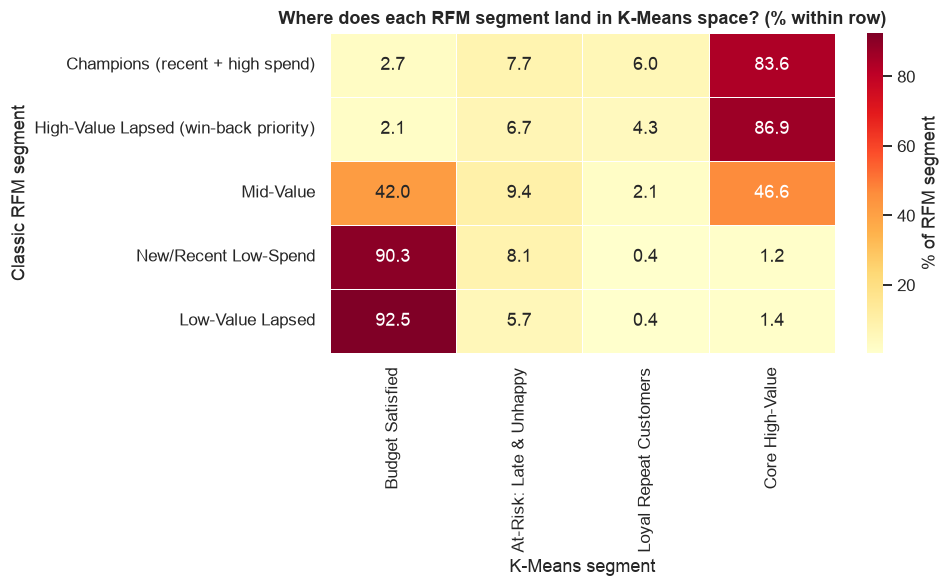

In [14]:
fig, ax = plt.subplots(figsize=(9, 5.5))
sns.heatmap(ct_pct, annot=True, fmt=".1f", cmap="YlOrRd", linewidths=0.5,
            cbar_kws={"label": "% of RFM segment"}, ax=ax)
ax.set_title("Where does each RFM segment land in K-Means space? (% within row)", fontweight="bold")
ax.set_xlabel("K-Means segment")
ax.set_ylabel("Classic RFM segment")
plt.tight_layout()
plt.show()

**FINDING #40 — "At-Risk: Late & Unhappy" customers are hiding inside every RFM segment,
including the best ones.** 7.7% of "Champions" (1,176 of 15,288 — recent, high-spend
customers) and 6.7% of "High-Value Lapsed" (973 of 14,446) land in the At-Risk K-Means
segment. By RFM alone, these **2,149 customers look like the marketplace's best or most
valuable** — recent purchases, large baskets. In reality, virtually every order they placed
arrived late and they rated the experience ~2.5/5. RFM has *no feature* that could ever
surface this: Recency and Monetary say nothing about delivery outcomes. Conversely, "Low-Value
Lapsed" and "New/Recent Low-Spend" customers are 90-93% "Budget Satisfied" — i.e., RFM's
two lowest-value segments are mostly customers having a *perfectly fine* low-stakes
experience, not a delivery problem. **The practical implication: an Amazon-style "win back
high-value lapsed customers" campaign that ignores delivery history would spend budget on
~1,000 customers whose actual blocker isn't price or recency — it's that their last
experience was a string of late deliveries.** Targeting Cluster 1 directly (regardless of RFM
segment) for a service-recovery offer (apology + expedited-shipping voucher) is a more
precisely targeted intervention than anything RFM alone could produce.

## 9. Regional composition of segments

NB3 found that Northeast/North Brazil systematically have thinner delivery-estimate buffers
and higher late rates than the Southeast/South core. If the "At-Risk: Late & Unhappy" segment
is driven by delivery failures, its regional mix should skew toward those regions relative to
the other three segments.

In [15]:
region_ct = pd.crosstab(cust_clean["segment"], cust_clean["region"], normalize="index") * 100
region_ct = region_ct.loc[seg_order, REGION_ORDER]
region_ct.round(2)

region,North,Northeast,Central-West,Southeast,South
segment,,,,,
Budget Satisfied,1.620,8.110,5.520,70.190,14.550
At-Risk: Late & Unhappy,2.210,16.680,5.770,62.880,12.460
Loyal Repeat Customers,1.360,6.560,6.140,71.150,14.780
Core High-Value,2.070,9.630,6.160,67.660,14.470


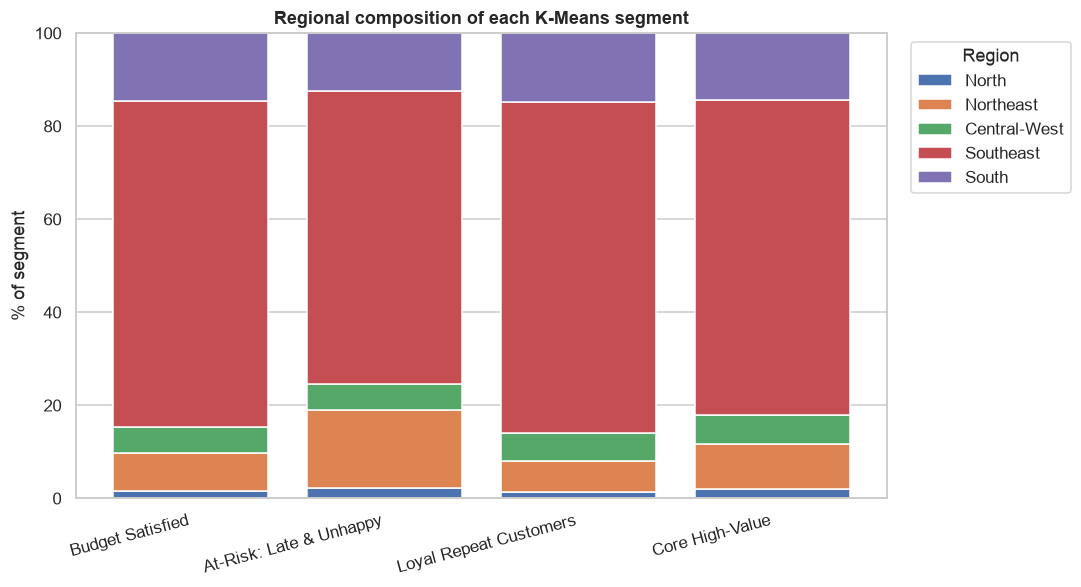

In [16]:
fig, ax = plt.subplots(figsize=(10, 5.5))
bottom = np.zeros(len(region_ct))
for region in REGION_ORDER:
    ax.bar(region_ct.index, region_ct[region], bottom=bottom, label=region, color=REGION_COLORS[region])
    bottom += region_ct[region].values

ax.set_ylabel("% of segment")
ax.set_title("Regional composition of each K-Means segment", fontweight="bold")
ax.legend(title="Region", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.set_ylim(0, 100)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

**FINDING #41 — The At-Risk segment is disproportionately Northeast Brazil, consistent
with NB3's delivery-buffer findings.** Northeast makes up **16.7% of the At-Risk segment**
vs. 6.6-9.6% of the other three segments — roughly **double its share of the satisfied
segments**. Southeast correspondingly drops to 62.9% of At-Risk vs. 67.7-71.2% elsewhere. This
isn't a new finding on its own (NB3 F25 already showed Northeast has the thinnest SLA buffers
and highest late rates), but it **closes the loop end-to-end**: a regional fulfillment
weakness (NB3) measurably produces a distinct, named customer segment with a 2.5-star review
gap (this notebook) — i.e., the same root cause shows up independently in the geographic and
the customer-behavioral views of the data. For Operations, this means a regional SLA-buffer
fix (NB3's recommendation) would disproportionately benefit exactly the customers most likely
to be at risk of churn.

## 10. Cluster stability — bootstrap Adjusted Rand Index

A silhouette of ~0.24 (Section 4) is modest, which raises a fair question: is this 4-cluster
structure *real*, or would a different random sample of customers produce a noticeably
different segmentation? To check, we bootstrap-resample the customer base 20 times (sampling
n=92,746 rows **with replacement** each time), refit K-Means (k=4) on each resample, predict
cluster labels for the **full original dataset** using each bootstrap model, and compute the
**Adjusted Rand Index (ARI)** against the original cluster assignments. ARI=1 means identical
partitions; ARI=0 means agreement no better than random.

In [17]:
boot_rng = np.random.RandomState(RANDOM_STATE)
aris = []
for i in range(20):
    idx = boot_rng.choice(len(X_scaled), size=len(X_scaled), replace=True)
    km_boot = KMeans(n_clusters=4, random_state=i, n_init=5)
    km_boot.fit(X_scaled[idx])
    boot_labels = km_boot.predict(X_scaled)
    aris.append(adjusted_rand_score(cust_clean["cluster"], boot_labels))

aris = np.array(aris)
print(f"Mean ARI: {aris.mean():.3f} | Std: {aris.std():.3f} | Min: {aris.min():.3f} | Max: {aris.max():.3f}")

Mean ARI: 0.979 | Std: 0.016 | Min: 0.936 | Max: 0.997


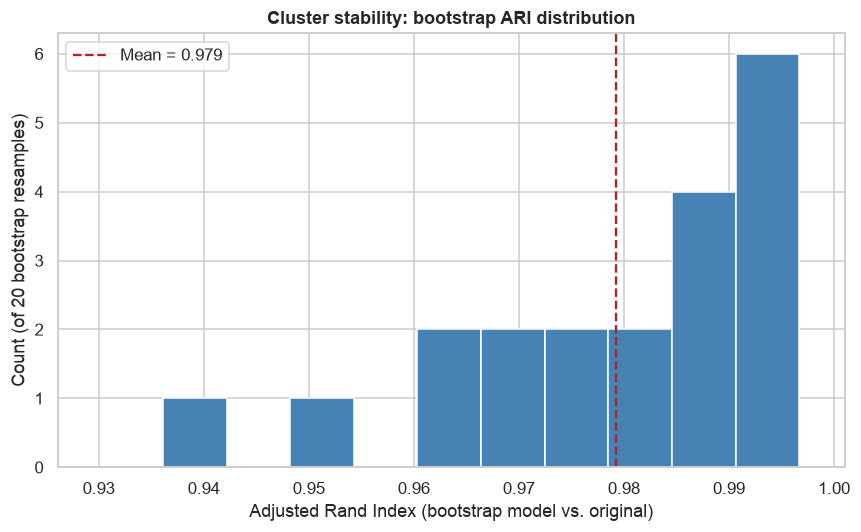

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(aris, bins=10, color="steelblue", edgecolor="white")
ax.axvline(aris.mean(), color="firebrick", linestyle="--", label=f"Mean = {aris.mean():.3f}")
ax.set_xlabel("Adjusted Rand Index (bootstrap model vs. original)")
ax.set_ylabel("Count (of 20 bootstrap resamples)")
ax.set_title("Cluster stability: bootstrap ARI distribution", fontweight="bold")
ax.set_xlim(aris.min() - 0.01, 1.001)
ax.legend()
plt.tight_layout()
plt.show()

**FINDING #42 — The segmentation is highly stable: mean bootstrap ARI = 0.979 (std =
0.016, range 0.936-0.997) across 20 resamples.** Despite a moderate silhouette score, the
4-cluster partition itself is **not an artifact of one random seed or one particular sample**
— refitting on 20 different bootstrap resamples of the customer base reproduces essentially
the same partition every time (ARI > 0.93 in the worst case, > 0.99 in the best). The modest
silhouette simply reflects that customer behavior is continuous rather than naturally
clumped into tight balls — but the *boundaries* K-Means draws through that continuum are
reproducible, which is what matters for using these segments operationally (e.g., scoring new
customers into segments going forward).

## 11. Segment-specific recommendations

| Segment | % Customers | % Revenue | Primary signal | Recommended action | Expected impact |
|---|---|---|---|---|---|
| **Core High-Value** | 44.5% | 69.5% | Excellent experience (review 4.27, 0.06% late), high spend, low freight burden | Loyalty / "Prime-style" enrollment offer at checkout; protect their SLA performance as a top monitoring priority | Convert a great one-off experience into a second purchase for the segment that already drives 7 of every 10 revenue dollars |
| **Budget Satisfied** | 45.1% | 17.7% | Equally great experience (review 4.33, highest of all segments) but small baskets and highest freight burden (28.6% of order value) | Free-shipping thresholds, bundle/cross-sell recommendations at checkout to lift basket size toward Core High-Value | Grow AOV for a segment that is already maximally satisfied — pure upside, no satisfaction risk to manage |
| **At-Risk: Late & Unhappy** | 7.9% | 8.3% | 99.7% of orders late (avg. 9.5 days), review 2.55/5 — and 2,149 of these customers are RFM "Champions"/"High-Value Lapsed" (F40) | Proactive service recovery (apology + expedited-shipping voucher) for affected customers; structurally, prioritize NB3's regional SLA-buffer fix for Northeast (F41) | Largest review-score recovery potential of any segment-level lever (NB4 F31: is_late carries a 1.7-star gap); directly protects ~2,150 high-value customers RFM would otherwise miss entirely |
| **Loyal Repeat Customers** | 2.5% | 4.6% | Only segment with real repeat behavior (71.5% have ordered 2+ times), highest per-customer lifetime value (R\$298), multi-category | VIP / early-access program, personalized cross-category recommendations | Highest-ROI retention spend — this is the only segment that has already proven it will come back |

## 12. Key Findings Summary

| # | Finding | Key numbers |
|---|---|---|
| 37 | Classic RFM (Recency x Monetary, Frequency excluded per Q2.1) recap | Champions + High-Value Lapsed = 32.1% of customers, 59.9% of revenue; High-Value Lapsed alone (15.6% of customers, avg. recency 398 days) is the largest single win-back opportunity by dollar value |
| 38 | k=4 chosen for K-Means via elbow + silhouette | Silhouette-maximizing at k=4 (0.240 vs. 0.190-0.223 for k=2,3,5-10); largest single-step inertia drop (k=3->4, -18.0%) |
| 39 | PCA recovers exactly the two axes this project has independently flagged as material | PC1 (27.9% var) = spend-level axis (log_monetary +0.58, avg_freight_ratio -0.46); PC2 (18.5% var) = delivery-experience axis (pct_late +0.64, avg_review_score -0.47) |
| 40 | "At-Risk: Late & Unhappy" customers are invisible to RFM — they're spread across every RFM segment | 7.7% of "Champions" and 6.7% of "High-Value Lapsed" (2,149 customers) are At-Risk: ~all orders late, review ~2.55/5 |
| 41 | At-Risk segment is disproportionately Northeast Brazil, closing the loop with NB3's geography findings | Northeast = 16.7% of At-Risk vs. 6.6-9.6% of the other three segments |
| 42 | Segmentation is highly stable across resamples | Mean bootstrap ARI = 0.979 (std 0.016, n=20 resamples) — moderate silhouette but reproducible boundaries |
| 43 | Four segments map to four distinct action plans | Core High-Value (44.5%/69.5% rev) -> loyalty enrollment; Budget Satisfied (45.1%/17.7%) -> basket-size growth; At-Risk (7.9%/8.3%) -> service recovery + regional SLA fix; Loyal Repeat (2.5%/4.6%) -> VIP retention |

### Overall takeaway

This notebook reframes the project's central finding — **late delivery is the dominant driver
of dissatisfaction (NB4 F31)** — from a population-level statistic into an **actionable,
named customer segment** that can be targeted directly, independent of how much a customer
spends or how recently they ordered. The crosstab in F40 is the sharpest illustration of why
this matters operationally: a CRM team working purely off an RFM export would never find these
2,149 at-risk "Champions," because nothing in an RFM table encodes delivery outcomes.

For **NB6 (predictive modeling)**, this notebook suggests two directions: (1) the
delivery-experience features built here (`pct_late`, `avg_delivery_delay_days`) are themselves
strong candidate *predictors* of low review score / churn risk at the customer level — but
since they are computed *after* delivery, the more operationally useful version is (2) a model
that predicts, **at order time**, the probability an order will be late (using
`estimated_delivery_days`, seller-customer distance, and other pre-delivery features from
NB3/NB4's H6 analysis) — which would let Operations flag at-risk *orders* before they ever
become at-risk *customers*.